# Gaussian Processes regression

## Dataset generation

In [7]:
import numpy as np

X = np.linspace(start=0, stop=10, num=1_000).reshape(-1, 1)
y = np.squeeze(X * np.sin(X))

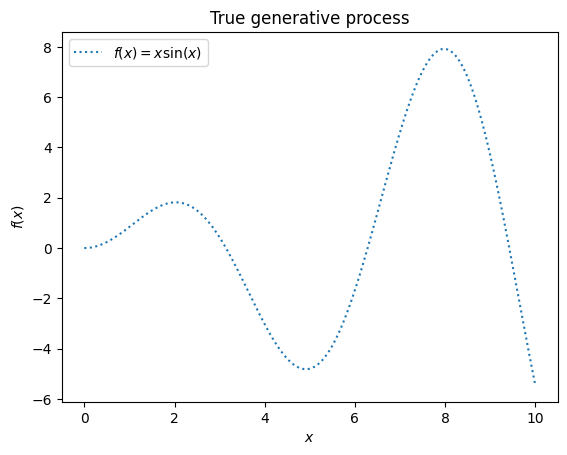

In [8]:
import matplotlib.pyplot as plt

plt.plot(X, y, label=r"$f(x) = x \sin(x)$", linestyle="dotted")
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("True generative process")

## Example with noise-free target

In [9]:
rng = np.random.RandomState(1) #Creates a random number generator with a fixed seed (1), to make the results reproducible 
training_indices = rng.choice(np.arange(y.size), size=6, replace=False)  #randomly selects 6 points from the dataset(size)
X_train, y_train = X[training_indices], y[training_indices] #extracts the 6 points as the training set, rest of the data is the true function for comparison 

In [10]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

##### Code here #####

kernel = RBF(length_scale=1.0)  #defines the kernel as a Radial Basis Function, it measures similarity between two inputs
gaussian_process = GaussianProcessRegressor(kernel=kernel) #creates the Gaussian model: it defines a distribution over possible functions
                                                           # Will calculate all the smooth curves that could fit the data, and how likely each one is
gaussian_process.fit(X_train, y_train)

gaussian_process.kernel_ #how the value at one point influences another point

RBF(length_scale=0.687)

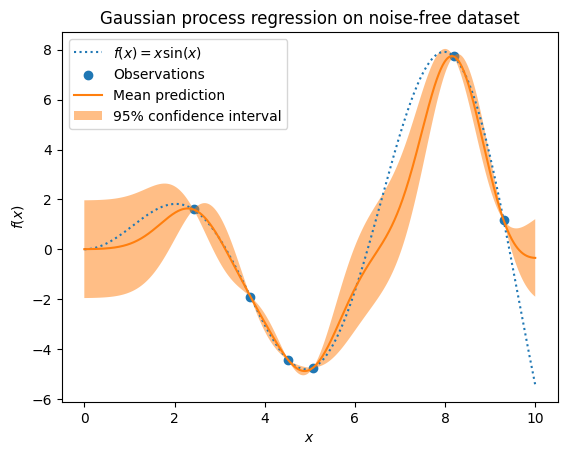

In [11]:
mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)

plt.plot(X, y, label=r"$f(x) = x \sin(x)$", linestyle="dotted")
plt.scatter(X_train, y_train, label="Observations")
plt.plot(X, mean_prediction, label="Mean prediction")
plt.fill_between(
    X.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.5,
    label=r"95% confidence interval",
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("Gaussian process regression on noise-free dataset")

# Gaussian process classification (GPC) on iris dataset

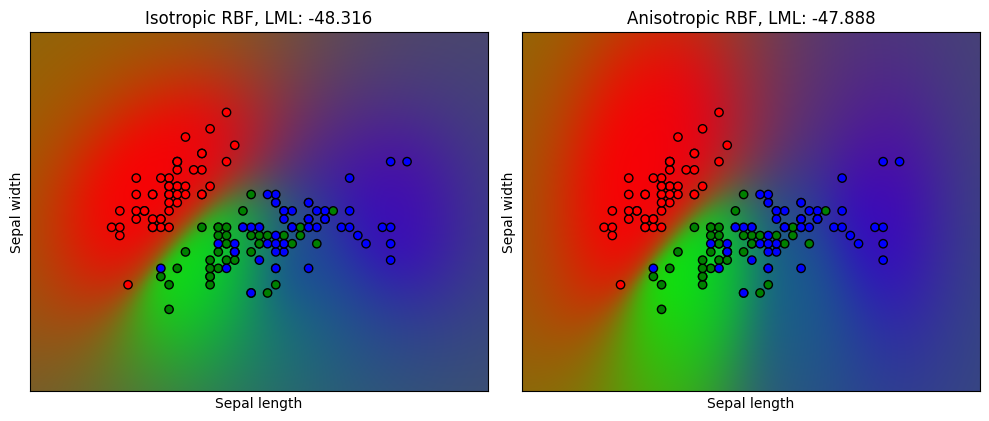

In [12]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn import datasets
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF

# import some data to play with
iris = datasets.load_iris()
X = iris.data[:, :2]  # we only take the first two features.
y = np.array(iris.target, dtype=int)

h = 0.02  # step size in the mesh

kernel = 1.0 * RBF([1.0])

##### Code here #####

# Isotropic kernel (same length scale for both features)
kernel_iso = 1.0 * RBF(length_scale=1.0)

gpc_rbf_isotropic = GaussianProcessClassifier(kernel=kernel_iso)
gpc_rbf_isotropic.fit(X, y)

# Anisotropic kernel (different length scales per feature)
kernel_aniso = 1.0 * RBF(length_scale=[1.0, 1.0])

gpc_rbf_anisotropic = GaussianProcessClassifier(kernel=kernel_aniso)
gpc_rbf_anisotropic.fit(X, y)

###########

# create a mesh to plot in
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

titles = ["Isotropic RBF", "Anisotropic RBF"]
plt.figure(figsize=(10, 5))
for i, clf in enumerate((gpc_rbf_isotropic, gpc_rbf_anisotropic)):
    # Plot the predicted probabilities. For that, we will assign a color to
    # each point in the mesh [x_min, m_max]x[y_min, y_max].
    plt.subplot(1, 2, i + 1)

    Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape((xx.shape[0], xx.shape[1], 3))
    plt.imshow(Z, extent=(x_min, x_max, y_min, y_max), origin="lower")

    # Plot also the training points
    plt.scatter(X[:, 0], X[:, 1], c=np.array(["r", "g", "b"])[y], edgecolors=(0, 0, 0))
    plt.xlabel("Sepal length")
    plt.ylabel("Sepal width")
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.title(
        "%s, LML: %.3f" % (titles[i], clf.log_marginal_likelihood(clf.kernel_.theta))
    )

plt.tight_layout()
plt.show()